<h1 align="center">
Uticaj augmentacije podataka na rezultate predviđanja godina čoveka na osnovu slike</h1>

<p align="center">
Diplomski rad - Neuronske mreže
</p>

<p align="left">
Mentor: dr Pavle Milošević</p>

<p align="right">
Student: Marija Minić 2022/0310</p>

**Cilj projekta:**  
Ispitati kako različite tehnike augmentacije utiču na performanse modela za procenu godina osobe na osnovu slike lica na Clean i Crop verziji IMDB-WIKI dataseta.

**Definicija problema:**  
Zadatak procene godina je formulisan kao regresioni problem:
- **Ulaz:** slika lica osobe
- **Izlaz:** jedan broj - procenjena starost osobe u godinama

**Metodologija:**
1. **Feature extractor** - MobileNet (pretreniran na ImageNet-u, bez top sloja) pretvara sliku iz piksela u vektor obeležja (feature vector). Koristi se transfer learning, mreža se ne trenira od nule, već se koristi kao "prevodilac" slika u brojeve.
2. **Regresioni modeli** - nad dobijenim vektorima obeležja treniraju se tri različita modela, kako bi se uporedile performanse različitih pristupa:
   - **MLPRegressor** - višeslojni perceptron (neuronska mreža)
   - **RandomForestRegressor** - *bagging* pristup; više stabala odlučivanja trenira se nezavisno, nad različitim podskupovima podataka, a finalna procena je prosek svih stabala
   - **XGBRegressor** - *boosting* pristup; stabla se treniraju sekvencijalno, gde svako novo stablo pokušava da ispravi grešku prethodnog
3. **Augmentacija podataka** - za trening skup se kreira više varijanti (bez augmentacije, horizontal flip, rotacija, promena osvetljenja, kombinacija svih), kako bi se ispitalo koja tehnika najviše doprinosi robusnosti modela.

Eksperiment se sprovodi na dve verzije IMDB-WIKI dataseta **crop (raw)** verziji i **clean** verziji, kako bi se, pored uticaja augmentacije, uporedio i uticaj kvaliteta/čistoće podataka na rezultate.


## 1. Uvod

<div style="background:#FDEEF4;padding:15px;border-left:5px solid #c702c790">

Augmentacija podataka **ne rešava** probleme u kvalitetu podataka, kao što su pogrešne godine ili loše kropovane slike (šum u podacima ostaje šum i posle augmentacije). 

Njena svrha je da model učini **otpornijim (robustnijim)** na varijacije koje se prirodno javljaju na slikama lica (nagnutu glavu, različito osvetljenje, orijentaciju lica), a ne da "očisti" pogrešno obeležene podatke.

</div>

## 2. Opis Dataseta

### 2.1 IMDB-WIKI Dataset

IMDB-WIKI dataset predstavlja jedan od najvećih javno dostupnih skupova podataka za procenu godina na osnovu slike lica. 
Sadrži slike poznatih ličnosti prikupljene sa IMDb i Wikipedije, pri čemu svaka slika poseduje pridruženu informaciju o starosti osobe.

U ovom radu dataset se koristi za rešavanje regresionog problema, gde je ulazna vrednost slika lica, dok je izlazna vrednost stvarna starost osobe izražena u godinama.

**Osnovni podaci o datasetu:**

- **Naziv:** IMDB-WIKI
- **Izvor:** slike prikupljene sa IMDb (filmske/TV ličnosti) i Wikipedije (javne ličnosti), objavio ETH Zürich (Rothe et al.)
- **Ukupna veličina:** originalni (crop/raw) deo sadrži preko 500.000 slika (IMDB ~460.000, WIKI ~62.000); clean (filtrirana) verzija je znatno manja, obično između ~150.000 i ~260.000 slika, zavisno od kriterijuma čišćenja
- **Format instance:** jedna instanca (slika lica, godina starosti u trenutku snimanja fotografije); godina se ne nalazi direktno u datasetu, već se izračunava iz datuma rođenja osobe i godine kada je fotografija snimljena; kod clean verzije dodatno su uklonjene slike sa nerealnim godinama, bez detektovanog lica ili sa više lica
- **Verzije korišćene:** crop (raw; slike isečene oko lica sa 40% margine, bez dodatnog čišćenja od strane autora); clean (slike i godine dodatno filtrirane, sa manjim dodatnim ručnim čišćenjem po potrebi)

### 2.2 Karakteristike i Izazovi Dataseta

IMDB-WIKI dataset sadrži određeni nivo šuma koji može negativno uticati na rezultate modela. 
Neke slike nisu precizno kropovane, dok pridružene godine ne moraju uvek odgovarati stvarnoj starosti osobe na slici.

Ovi nedostaci predstavljaju izazov za model, jer performanse zavise ne samo od arhitekture modela već i od kvaliteta ulaznih podataka.

**Konkretni problemi identifikovani u datasetu:**

- **Šum u godinama**: starost se u obe verzije računa iz razlike datuma rođenja i godine snimanja fotografije, uz pretpostavku da je slika snimljena sredinom te godine - ovo unosi grešku od ±0.5 godina po instanci u oba slučaja; kod crop verzije dodatno postoje i pogrešno upisani datumi rođenja (npr. nerealne vrednosti poput datuma 47 u matlab formatu), dok su takvi ekstremni slučajevi u clean verziji već uklonjeni
- **Netačne/nerealne godine**: u crop verziji deo instanci ima negativne ili nerealno velike godine (>100), koje su morale biti naknadno uklonjene; u clean verziji su ovakve instance već filtrirane u procesu pravljenja dataseta, pa ih gotovo da nema
- **Slike sa više lica**: second_face_score polje ukazuje na prisustvo drugog lica pored glavnog; u crop verziji ove instance su izbačene ručno u nastavku rada, dok su u clean verziji već filtrirane pri kreiranju dataseta
- **Loše detektovana lica**: face_score sa vrednošću -Inf označava da lice uopšte nije pouzdano detektovano; u crop verziji ove instance su naknadno uklonjene, dok su u clean verziji već izbačene u procesu
- **Loše kropovane slike**: u obe verzije deo slika i dalje sadrži pozadinu, više osoba u kadru, ili je lice delimično van kadra, jer se filtriranje (bilo crop, bilo clean) ne bavi vizuelnim kvalitetom kropa
- **Različiti uslovi osvetljenja i pozicije lica**: u obe verzije slike su snimljene u različitim kontekstima (crveni tepih, portreti, snapshot fotografije), pa variraju u osvetljenju, uglu snimanja i pozi lica, jer nijedan proces čišćenja ne standardizuje vizuelne uslove snimanja

Razlika između verzija je u tome što je clean verzija prošla kroz automatsko filtriranje metapodataka (godine, broj lica, pouzdanost detekcije) još pre nego što je uopšte korišćena u ovom radu.

### 2.3 Verzije Dataseta i Strategija Izbora

U početnoj fazi rada korišćena je kropovana (raw) verzija IMDB-WIKI dataseta, sa ciljem da se smanji uticaj pozadine i fokus modela usmeri na karakteristike lica.

Pre primene tehnika augmentacije izvršena je analiza dataseta kako bi se proverio kvalitet slika, dostupnost starosnih oznaka i postojanje potencijalnih problema u podacima.

Umesto da se unapred odabere samo jedna verzija dataseta, ceo pajplajn (augmentacija, ekstrakcija obeležja, treniranje modela) će se sprovesti na obe verzije, crop (raw) i clean, kako bi se njihovi rezultati mogli direktno uporediti.

## 3. Crop (raw) verzija

### 3.1. Učitavanje i čišćenje

In [1]:
import scipy.io # za mat fajlove
import pandas as pd
import numpy as np

imdb_mat = scipy.io.loadmat("imdb_crop/imdb.mat") # ucitavamo imdb deo
imdb_data = imdb_mat["imdb"][0, 0] # sad mozemo kolone da vadimo

# sve kolone iz imdba
imdb_dob = imdb_data["dob"][0]
imdb_photo_taken = imdb_data["photo_taken"][0]
imdb_full_path = imdb_data["full_path"][0]
imdb_gender = imdb_data["gender"][0]
imdb_face_score = imdb_data["face_score"][0]
imdb_second_face_score = imdb_data["second_face_score"][0]

wiki_mat = scipy.io.loadmat("wiki_crop/wiki.mat") # ucitavamo wiki deo
wiki_data = wiki_mat["wiki"][0, 0] # mozemo kolone

# sve kolone iz wikija
wiki_dob = wiki_data["dob"][0]
wiki_photo_taken = wiki_data["photo_taken"][0]
wiki_full_path = wiki_data["full_path"][0]
wiki_gender = wiki_data["gender"][0]
wiki_face_score = wiki_data["face_score"][0]
wiki_second_face_score = wiki_data["second_face_score"][0]

In [2]:
df_imdb = pd.DataFrame({
    "dob": imdb_dob,
    "photo_taken": imdb_photo_taken,
    "path": imdb_full_path,
    "gender": imdb_gender,
    "face_score": imdb_face_score,
    "second_face_score": imdb_second_face_score,
    "source": "imdb"
}) # pravimo tabelu sa imdb kolonama

df_wiki = pd.DataFrame({
    "dob": wiki_dob,
    "photo_taken": wiki_photo_taken,
    "path": wiki_full_path,
    "gender": wiki_gender,
    "face_score": wiki_face_score,
    "second_face_score": wiki_second_face_score,
    "source": "wiki"
}) # pravimo tabelu sa wiki kolonama

df = pd.concat(
    [df_imdb, df_wiki],
    ignore_index=True
) # spajamo imdb i wiki

# odmah sredjujemo putanju do slike,dodajemo odgovarajuci folder u zavisnosti od izvora
def fix_path(row): # prima red
    x = row["path"]

    # ako je numpy niz, uzimamo prvi element
    if isinstance(x, np.ndarray):
        x = x[0]

    x = str(x)

    if row["source"] == "imdb": # dodajemo odg folder
        return "imdb_crop/" + x
    else:
        return "wiki_crop/" + x

df["path"] = df.apply(fix_path, axis=1) # primenjujemo fju na ceo df

# ispravljamo  dupliran folder u putanji 
df["path"] = df["path"].str.replace("imdb_crop/imdb_crop/", "imdb_crop/")
df["path"] = df["path"].str.replace("wiki_crop/wiki_crop/", "wiki_crop/")

# velicine dfova
print("IMDB:", df_imdb.shape)
print("WIKI:", df_wiki.shape)
print("Ukupno IMDB-WIKI:", df.shape)

df.head()

IMDB: (460723, 7)
WIKI: (62328, 7)
Ukupno IMDB-WIKI: (523051, 7)


,dob,photo_taken,path,gender,face_score,second_face_score,source
0,693726,1968,imdb_crop/01/nm0000001_rm124825600_1899-5-10_1...,1.0,1.459693,1.118973,imdb
1,693726,1970,imdb_crop/01/nm0000001_rm3343756032_1899-5-10_...,1.0,2.543198,1.852008,imdb
2,693726,1968,imdb_crop/01/nm0000001_rm577153792_1899-5-10_1...,1.0,3.455579,2.985660,imdb
3,693726,1968,imdb_crop/01/nm0000001_rm946909184_1899-5-10_1...,1.0,1.872117,NaN,imdb
4,693726,1968,imdb_crop/01/nm0000001_rm980463616_1899-5-10_1...,1.0,1.158766,NaN,imdb


In [3]:
print("Broj slika:", len(df))

Broj slika: 523051


In [4]:
# provera vrednosti datuma rodj za imdb

print("IMDB dob:", imdb_dob[:10])
print("IMDB Min:", np.nanmin(imdb_dob))
print("IMDB Max:", np.nanmax(imdb_dob))
print("IMDB NaN:", np.isnan(imdb_dob).sum())


# provera vrednosti datuma rodj za wiki 
print("\nWIKI dob:", wiki_dob[:10])
print("WIKI Min:", np.nanmin(wiki_dob))
print("WIKI Max:", np.nanmax(wiki_dob))
print("WIKI NaN:", np.isnan(wiki_dob).sum())


# provera spojenog
print("\nIMDB-WIKI ukupno:")
print("Min:", np.nanmin(df["dob"]))
print("Max:", np.nanmax(df["dob"]))
print("NaN:", df["dob"].isna().sum())

# spojena sadrži šum

IMDB dob: [693726 693726 693726 693726 693726 702986 702986 702986 702986 702986]
IMDB Min: 47
IMDB Max: 734963
IMDB NaN: 0

WIKI dob: [723671 703186 711677 705061 720044 716189 707745 695763 711000 723987]
WIKI Min: 4077
WIKI Max: 736011
WIKI NaN: 0

IMDB-WIKI ukupno:
Min: 47
Max: 736011
NaN: 0


In [5]:
import datetime

def matlab_datenum_to_date(datenum): # fja koja sluzi da kod ne pukne kad naidje na los datum
    try:
        if np.isnan(datenum):
            return None
        
        return datetime.datetime.fromordinal( # iz matlab formata datuma pretvara u normalan format
            int(datenum)
        ) + datetime.timedelta(days=datenum % 1) - datetime.timedelta(days=366)
    
    except:
        return None

In [6]:
df['birth_date'] = df['dob'].apply(matlab_datenum_to_date) # pretvaramo u normalan format za datum

In [7]:
df["birth_date"] = pd.to_datetime(
    df["birth_date"],
    errors="coerce"
) # pretvaramo u pandas datetime

print(df["birth_date"].dtype)
print("Nevalidni datumi:", df["birth_date"].isna().sum())

datetime64[ns]
Nevalidni datumi: 154


In [8]:
df['age'] = df['photo_taken'] - df['birth_date'].dt.year # racunamo starost osobe

In [9]:
df[['age', 'photo_taken', 'birth_date']].head() # provera dobijenih godina

,age,photo_taken,birth_date
0,69.0,1968,1899-05-10
1,71.0,1970,1899-05-10
2,69.0,1968,1899-05-10
3,69.0,1968,1899-05-10
4,69.0,1968,1899-05-10


In [10]:
df['age'].describe()

count    522897.000000
mean         36.895128
std          14.211969
min         -74.000000
25%          27.000000
50%          35.000000
75%          45.000000
max         322.000000
Name: age, dtype: float64

In [11]:
df = df[(df['age'] > 0) & (df['age'] < 100)] # uklanjanje nepravilnih vrednosti

In [12]:
print("Broj slika nakon čišćenja:", len(df)) # provera koliko slika je ostalo

Broj slika nakon čišćenja: 520427


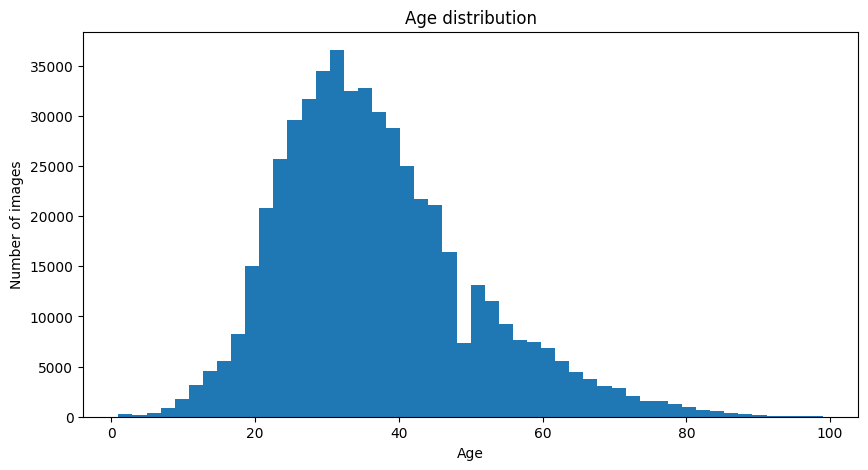

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(df['age'], bins=50)

plt.xlabel("Age")
plt.ylabel("Number of images")
plt.title("Age distribution")

plt.show() # distribucija godina

In [14]:
# proveravamo putanje 
print("Prva IMDB putanja:")
print(df[df["source"] == "imdb"]["path"].iloc[0])

print("\nPrva WIKI putanja:")
print(df[df["source"] == "wiki"]["path"].iloc[0])

Prva IMDB putanja:
imdb_crop/01/nm0000001_rm124825600_1899-5-10_1968.jpg

Prva WIKI putanja:
wiki_crop/17/10000217_1981-05-05_2009.jpg


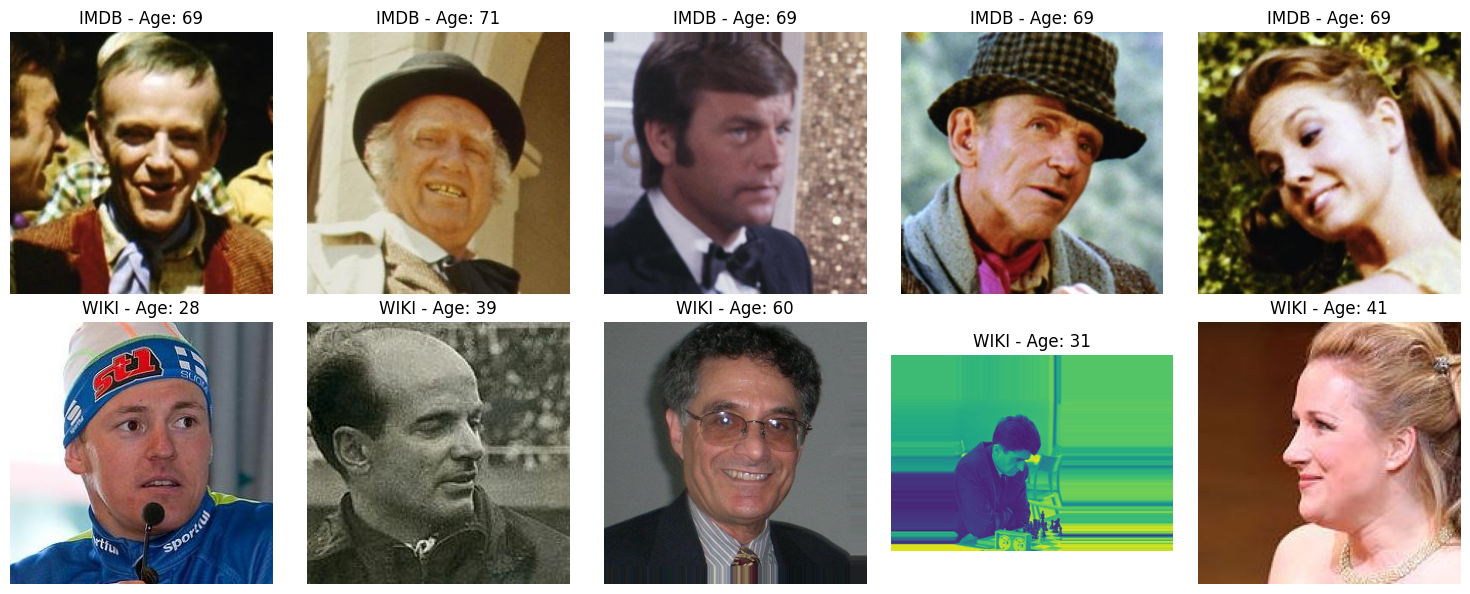

In [15]:
from PIL import Image
import matplotlib.pyplot as plt

# uzimamo 5 imdb i 5 wiki slika
imdb_sample = df[df["source"] == "imdb"].head(5)
wiki_sample = df[df["source"] == "wiki"].head(5)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

# prvi red imdb
for i, (_, row) in enumerate(imdb_sample.iterrows()):
    img = Image.open(row["path"])

    axes[0, i].imshow(img)
    axes[0, i].set_title(f"IMDB - Age: {row['age']:.0f}")
    axes[0, i].axis("off")

# drugi red wiki
for i, (_, row) in enumerate(wiki_sample.iterrows()):
    img = Image.open(row["path"])

    axes[1, i].imshow(img)
    axes[1, i].set_title(f"WIKI - Age: {row['age']:.0f}")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

In [16]:
df.head()

,dob,photo_taken,path,gender,face_score,second_face_score,source,birth_date,age
0,693726,1968,imdb_crop/01/nm0000001_rm124825600_1899-5-10_1...,1.0,1.459693,1.118973,imdb,1899-05-10,69.0
1,693726,1970,imdb_crop/01/nm0000001_rm3343756032_1899-5-10_...,1.0,2.543198,1.852008,imdb,1899-05-10,71.0
2,693726,1968,imdb_crop/01/nm0000001_rm577153792_1899-5-10_1...,1.0,3.455579,2.985660,imdb,1899-05-10,69.0
3,693726,1968,imdb_crop/01/nm0000001_rm946909184_1899-5-10_1...,1.0,1.872117,NaN,imdb,1899-05-10,69.0
4,693726,1968,imdb_crop/01/nm0000001_rm980463616_1899-5-10_1...,1.0,1.158766,NaN,imdb,1899-05-10,69.0


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 520427 entries, 0 to 523050
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   dob                520427 non-null  int32         
 1   photo_taken        520427 non-null  uint16        
 2   path               520427 non-null  object        
 3   gender             509498 non-null  float64       
 4   face_score         520427 non-null  float64       
 5   second_face_score  217624 non-null  float64       
 6   source             520427 non-null  object        
 7   birth_date         520427 non-null  datetime64[ns]
 8   age                520427 non-null  float64       
dtypes: datetime64[ns](1), float64(4), int32(1), object(2), uint16(1)
memory usage: 34.7+ MB


In [18]:
df.isna().sum()

dob                       0
photo_taken               0
path                      0
gender                10929
face_score                0
second_face_score    302803
source                    0
birth_date                0
age                       0
dtype: int64

In [19]:
# filtriramo slike gde je detektovano vise od jednog lica (second_face_score nije NaN)
# ako second_face_score ima vrednost, ima i drugo lice na slici 
print("Slika sa vise lica (pre filtriranja):", df['second_face_score'].notna().sum())

df = df[df['second_face_score'].isna()] # izbacujemo slike sa vise lica

print("Broj slika nakon uklanjanja slika sa vise lica:", len(df))

Slika sa vise lica (pre filtriranja): 217624
Broj slika nakon uklanjanja slika sa vise lica: 302803


In [20]:
df = df.drop('second_face_score', axis=1) 
# brisemo sada tu kolonu

In [21]:
df.shape

(302803, 8)

In [22]:
df['age'].describe()
# ima 302803 slika sa upisanom staroscu
# prosecna starost oko 37 godina
# starosti rasporedjene oko proseka
# najmladja osoba ima oko 1 godinu
# najstarija osoba ima oko 99 godina

count    302803.000000
mean         36.817707
std          13.784928
min           1.000000
25%          27.000000
50%          35.000000
75%          44.000000
max          99.000000
Name: age, dtype: float64

In [23]:
df.duplicated().sum() # nema duplikata u datasetu

np.int64(0)

In [24]:
df['path'].duplicated().sum() # nema duplikata po slici

np.int64(0)

In [25]:
df['gender'].value_counts()

gender
1.0    181557
0.0    114699
Name: count, dtype: int64

In [26]:
# napravicu posebnu kolonu u kojoj ce mi biti osobe kojima ne znam pol u kojoj cemo 
# imati vrednost -1, jer mi je bitno da imam sto vise slika da bi tacnost modela bila bolja
df['gender'] = df['gender'].fillna(-1)

In [27]:
df.isna().sum()

dob            0
photo_taken    0
path           0
gender         0
face_score     0
source         0
birth_date     0
age            0
dtype: int64

In [28]:
df['gender'].value_counts()
# gotov je deo sa nedostajucim vrednostima

gender
 1.0    181557
 0.0    114699
-1.0      6547
Name: count, dtype: int64

In [29]:
# provera kvaliteta slika i podataka pre modela

# face score nam govori koliko je lice dobro detektovano, ako su niske vrednosti nije dobro
df['face_score'].describe()

# vidimo da imam beskonacne negativne vrednosti, a to nisu validni podaci pa treba da ih ocistimo

/Users/marijaminic/miniconda3/envs/diplomski/lib/python3.10/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/Users/marijaminic/miniconda3/envs/diplomski/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:4779: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


count    3.028030e+05
mean             -inf
std               NaN
min              -inf
25%               NaN
50%      2.352750e+00
75%      3.784419e+00
max      7.381689e+00
Name: face_score, dtype: float64

In [30]:
np.isinf(df['face_score']).sum() # koliko ih ima

np.int64(78256)

In [31]:
df = df[~np.isinf(df['face_score'])] # izbacimo sve osim validnih

In [32]:
df['face_score'].describe() # sada je sredjen
# ali izgubili smo 302803 - 224547 = 78256 redova

count    224547.000000
mean          3.116098
std           1.345292
min           0.730919
25%           2.007854
50%           3.099786
75%           4.173981
max           7.381689
Name: face_score, dtype: float64

In [33]:
df.isnull().sum()

dob            0
photo_taken    0
path           0
gender         0
face_score     0
source         0
birth_date     0
age            0
dtype: int64

In [34]:
df.shape

(224547, 8)

In [35]:
df.head()

,dob,photo_taken,path,gender,face_score,source,birth_date,age
3,693726,1968,imdb_crop/01/nm0000001_rm946909184_1899-5-10_1...,1.0,1.872117,imdb,1899-05-10,69.0
4,693726,1968,imdb_crop/01/nm0000001_rm980463616_1899-5-10_1...,1.0,1.158766,imdb,1899-05-10,69.0
6,702986,2004,imdb_crop/02/nm0000002_rm1346607872_1924-9-16_...,0.0,3.479189,imdb,1924-09-16,80.0
7,702986,2004,imdb_crop/02/nm0000002_rm1363385088_1924-9-16_...,0.0,3.870171,imdb,1924-09-16,80.0
12,702986,1974,imdb_crop/02/nm0000002_rm221957120_1924-9-16_1...,0.0,4.096431,imdb,1924-09-16,50.0


#### 3.1.1. Uzorkovanje podskupa

Pošto pun eksperiment (5 augmentacionih varijanti x 3 modela x 2 dataseta) dugo traje, 'USE_SUBSET' prekidač omogućava da se kod prvo testira i razvija na manjem, balansiranom podskupu (brzo, u minutima), a zatim pusti finalni run na celom datasetu ('USE_SUBSET = False').

In [ ]:
USE_SUBSET = False   # True dok testiram
SUBSET_SIZE = 9000
RANDOM_STATE = 42

if USE_SUBSET:
    # pravimo starosne bin-ove da bi uzorak bio ravnomerno rasporedjen po godinama
    df['age_bin'] = pd.cut(df['age'], bins=10)

    df_subset = (
        df.groupby('age_bin', observed=True, group_keys=False)
          .apply(lambda x: x.sample(
              n=min(len(x), SUBSET_SIZE // df['age_bin'].nunique()),
              random_state=RANDOM_STATE
          ))
    )

    df_subset = df_subset.drop(columns=['age_bin']).reset_index(drop=True)
else:
    # koristimo ceo dataset
    df_subset = df.reset_index(drop=True)

print("Broj slika koje se koriste:", len(df_subset))
df_subset['age'].describe()

Broj slika koje se koriste: 224547


count    224547.000000
mean         37.257011
std          13.748444
min           1.000000
25%          27.000000
50%          35.000000
75%          45.000000
max          99.000000
Name: age, dtype: float64

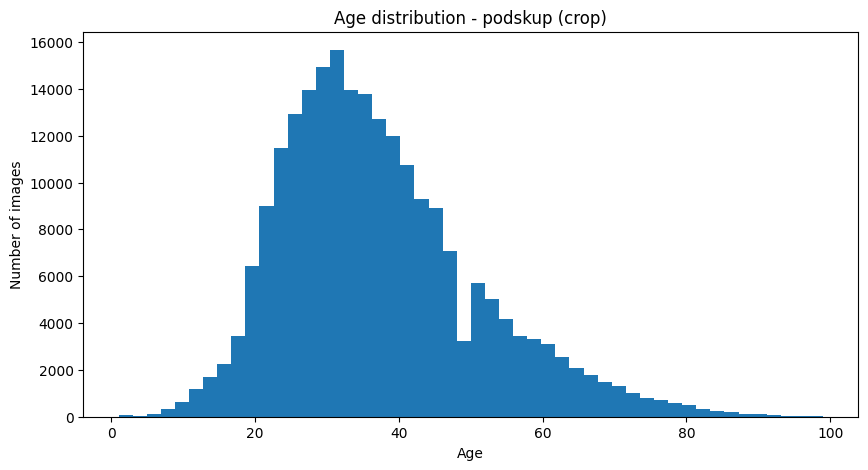

In [37]:
plt.figure(figsize=(10,5))
plt.hist(df_subset['age'], bins=50)
plt.xlabel("Age")
plt.ylabel("Number of images")
plt.title("Age distribution - podskup (crop)")
plt.show()

#### 3.1.2. Podela Dataseta (split)

Dataset je podeljen na trening i test skup (85% / 15%).

Trening skup se koristi za učenje modela i za 10-struku unakrsnu validaciju (10-fold CV), kojom se poredi 5 augmentacionih varijanti x 3 modela. Test skup se koristi isključivo za konačnu procenu performansi najbolje kombinacije (test skup se ne koristi ni u jednom trenutku pre finalne evaluacije).

Za izbor najbolje augmentacione varijante i modela koristimo 10-fold CV nad trening skupom, čime se izbegava i potreba za dodatnim optimizacionim metodama za podešavanje hiperparametara.

Split se radi pre augmentacije, kako bi se izbeglo curenje podataka (data leakage), da augmentovana verzija neke slike ne završi u drugom skupu od originala.

In [38]:
X = df_subset['path']
y = df_subset['age']

print(X.head())
print(y.head())

0    imdb_crop/01/nm0000001_rm946909184_1899-5-10_1...
1    imdb_crop/01/nm0000001_rm980463616_1899-5-10_1...
2    imdb_crop/02/nm0000002_rm1346607872_1924-9-16_...
3    imdb_crop/02/nm0000002_rm1363385088_1924-9-16_...
4    imdb_crop/02/nm0000002_rm221957120_1924-9-16_1...
Name: path, dtype: object
0    69.0
1    69.0
2    80.0
3    80.0
4    50.0
Name: age, dtype: float64


In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=RANDOM_STATE
)
# delimo na 85% trening i 15% test skup

In [40]:
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(190864,)
(33683,)
(190864,)
(33683,)


#### 3.1.3. Priprema slika za MobileNet

MobileNet je pretreniran sa 'preprocess_input' funkcijom koja skalira piksele u opseg [-1, 1], ako se koristi pogrešna normalizacija, pretrenirani filteri ne rade optimalno i dobijeni feature vektori su lošijeg kvaliteta.

In [13]:
import tensorflow as tf
from tensorflow.keras.applications.mobilenet import preprocess_input

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

def load_image(path, label):
    img = tf.io.read_file(path) # cita fajl sa diska
    img = tf.image.decode_jpeg(img, channels=3) # dekodira jpeg u rgb
    img = tf.image.resize(img, IMG_SIZE) # menja dimenzije 
    img = preprocess_input(img) # skalira u [-1, 1]
    return img, label

In [42]:
# testiramo na 1 slici
img_raw = tf.io.read_file(X_train.iloc[0])
img_raw = tf.image.decode_jpeg(img_raw, channels=3)
img_raw = tf.image.resize(img_raw, IMG_SIZE)
img_pp = preprocess_input(img_raw)

print("Min/Max pre preprocess_input:", float(tf.reduce_min(img_raw)), float(tf.reduce_max(img_raw)))
print("Min/Max posle preprocess_input:", float(tf.reduce_min(img_pp)), float(tf.reduce_max(img_pp)))

# sve super prebaceno je u interval [-1, 1]

Min/Max pre preprocess_input: 0.0 255.0
Min/Max posle preprocess_input: -1.0 1.0


2026-08-23 17:12:21.189692: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2026-08-23 17:12:21.189735: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-08-23 17:12:21.189745: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
I0000 00:00:1787497941.189761 1035198 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1787497941.189793 1035198 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


#### 3.1.4. Augmentacione varijante trening skupa

Da bi ispitali uticaj pojedinačnih tehnika augmentacije, kreirala sam više verzija trening dataseta:

| Varijanta | Primena |
|---|---|
| Original | Bez augmentacije |
| Flip | Horizontal flip |
| Rotation | Rotacija (±10%, ~36°) |
| Brightness | Promena osvetljenja |
| Combined | Sve transformacije zajedno |

Augmentacija se primenjuje isključivo na trening skup. Test skup ostaje uvek originalan (bez augmentacije), jer se na njemu meri kako se model ponaša na realnim, neizmenjenim slikama.


Svaka varijanta koristi isti 'test_ds'. Poređenje varijanti (koja augmentacija najviše doprinosi) radi se 10-strukom unakrsnom validacijom nad trening skupom.

In [16]:
from tensorflow.keras import layers # za randflip, ...

flip_aug = layers.RandomFlip("horizontal")
rotation_aug = layers.RandomRotation(0.1)
brightness_aug = layers.RandomBrightness(0.6)

combined_aug = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomBrightness(0.6)
])

# recnik svih varijanti bez augmentacije
AUGMENTATIONS = {
    "original": None,
    "flip": flip_aug,
    "rotation": rotation_aug,
    "brightness": brightness_aug,
    "combined": combined_aug,
}

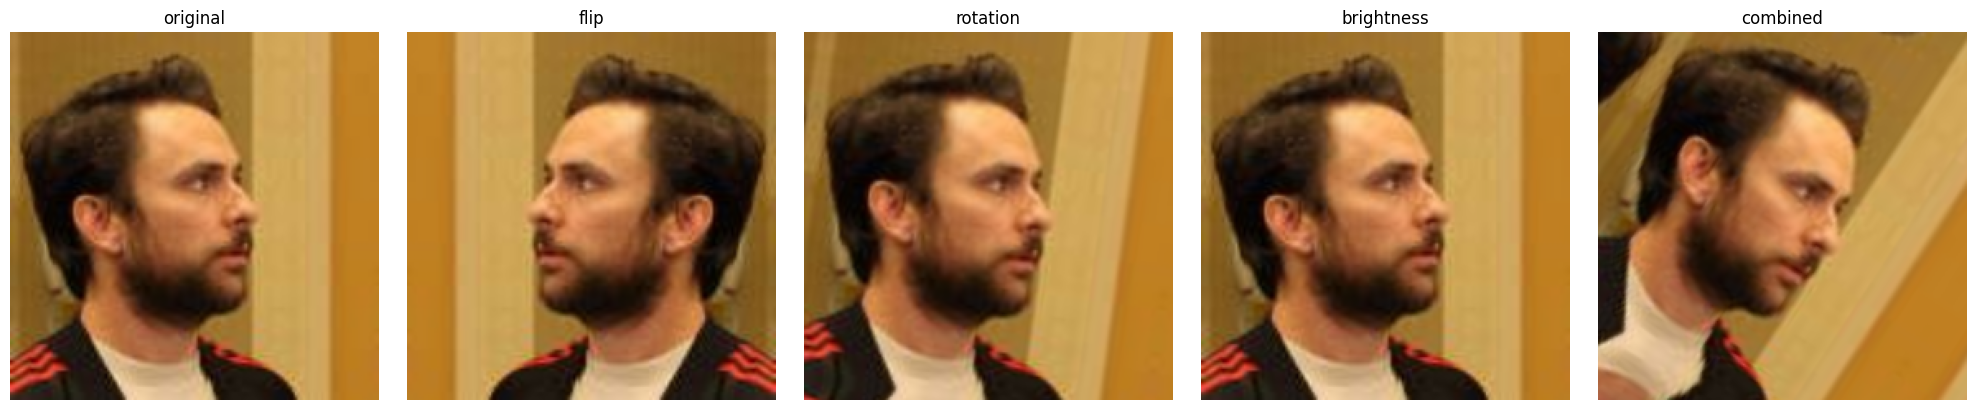

In [45]:
# na jednoj slici da vizuelno proverimo da augmentacije rade kako treba
img_demo = tf.expand_dims(img_pp, axis=0)

fig, axes = plt.subplots(1, len(AUGMENTATIONS), figsize=(20, 4))

for ax, (name, aug_layer) in zip(axes, AUGMENTATIONS.items()):
    if aug_layer is None:
        shown = img_demo[0] # ako nije aug onda org uzimamo
    else:
        shown = aug_layer(img_demo, training=True)[0] # ako nije org slika primenjujemo aug
    # vracamo iz [-1,1] u [0,1] zbog prikaza slike
    min_val = tf.reduce_min(shown)
    max_val = tf.reduce_max(shown)
    shown_display = (shown - min_val) / (max_val - min_val)

    ax.imshow(shown_display) # prikazivanje...
    ax.set_title(name)
    ax.axis("off")
    
plt.tight_layout()
plt.show()

In [14]:
def load_image_with_aug(path, label, aug_layer=None):
    # ucitava sliku, radi resize + preprocess_input, opciono primenjuje augmentaciju
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE) # pretvaramo u format koji nam treba sliku

    if aug_layer is not None: # provera da li treba aug
        img = aug_layer(tf.expand_dims(img, 0), training=True)[0] # primenimo

    img = preprocess_input(img) # transformacija u [-1,1]
    
    return img, label

def make_dataset(paths, labels, aug_layer=None, batch_size=BATCH_SIZE, shuffle=False):
    # pravi tf dataset od putanja i labela uz opcionu augmentaciju
    ds = tf.data.Dataset.from_tensor_slices((paths.values, labels.values))

    if shuffle: # ako mesamo podatke
        ds = ds.shuffle(buffer_size=len(paths), seed=RANDOM_STATE)

    ds = ds.map( # ucitavanje i obrada svake slike
        lambda p, l: load_image_with_aug(p, l, aug_layer),
        num_parallel_calls=tf.data.AUTOTUNE
    )
    ds = ds.batch(batch_size) # grupisanje slika
    ds = ds.prefetch(tf.data.AUTOTUNE) # ubrzavanje

    return ds

In [47]:
# test skup bez augmentacije pravi se jednom
test_ds = make_dataset(X_test, y_test, aug_layer=None)

# train skup, po jedna verzija za svaku augmentacionu varijantu
train_datasets = {
    name: make_dataset(X_train, y_train, aug_layer=aug_layer, shuffle=True)
    for name, aug_layer in AUGMENTATIONS.items()
}

print("Napravljeno train_ds varijanti:", list(train_datasets.keys()))

Napravljeno train_ds varijanti: ['original', 'flip', 'rotation', 'brightness', 'combined']


In [48]:
# brza provera dimenzija na jednoj varijanti
for images, labels in train_datasets["original"].take(1):
    print("Dimenzije slika:", images.shape)
    print("Dimenzije labela:", labels.shape)

Dimenzije slika: (32, 224, 224, 3)
Dimenzije labela: (32,)


2026-08-23 17:12:42.241714: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


#### 3.1.5. MobileNet - ekstrakcija obeležja (feature extraction)

In [22]:
from tensorflow.keras.applications import MobileNet # uvozim mobilenet (konvolucionu nm za obradu slika)
from tensorflow.keras import Model # za pravljenje modela
from tensorflow.keras.layers import GlobalAveragePooling2D # uzima izlaz iz cnna i pretvara ga u numericki vektor

base_model = MobileNet(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
) # pravljenje modela

base_model.trainable = False # zamrzne se da se ne bi menjale tezine tokom treniranja

feature_extractor = Model( # pravim model koji uzima model mn za ulaz, a karakteristike slike za izlaz
    inputs=base_model.input,
    outputs=GlobalAveragePooling2D()(base_model.output)
)
# Sada se prolazi kroz ceo dataset (svaku augmentacionu varijantu) i svi feature vektori 
# se čuvaju na disk (.npy), da se ovaj korak ne mora ponavljati pri svakom narednom treniranju modela

In [20]:
import os # bibl za fajlove i foldere

FEATURES_DIR = "features_crop" # def foldera
os.makedirs(FEATURES_DIR, exist_ok=True) # pravljenje foldera

def extract_features(dataset, feature_extractor):
    all_features, all_labels = [], [] # pravimo 2 prazne liste

    for images, labels in dataset:  # prolazmo kroz ceo dataset 
        feats = feature_extractor.predict(images, verbose=0) # izvlacimo feature
        all_features.append(feats) # ubacujemo ih u listu
        all_labels.append(labels.numpy()) # godine ubacujemo u listu

    return np.concatenate(all_features), np.concatenate(all_labels) # spajamo sve batcheve 
# vraca (X_features, y_labels) kao numpy nizove

In [52]:
# test slike provlacim kroz mobilenet (samo jednom) i cuvam feature na disk
X_test_feat, y_test_feat = extract_features(test_ds, feature_extractor)

np.save(f"{FEATURES_DIR}/test_features.npy", X_test_feat) # cuvamo test feature
np.save(f"{FEATURES_DIR}/test_labels.npy", y_test_feat) # cuvamo test labele

# ispisujemo dimenzije
print("Test features:", X_test_feat.shape)

2026-08-23 17:12:54.116646: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


Test features: (33683, 1024)


2026-08-23 17:14:43.253271: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [53]:
# train, ekstrakcija za svih 5 augmentacionih varijanti
train_features = {} # da bi cuvali vektore za svaku aug varijantu
train_labels = {} # za cuvanje godina

for name, ds in train_datasets.items(): # prolazimo kroz augmentacije
    print(f"Ekstrakcija obelezja za varijantu: {name} ...") # ime aug
    X_feat, y_feat = extract_features(ds, feature_extractor) # izvlacimo feature

    train_features[name] = X_feat # cuvamo feature u recnik
    train_labels[name] = y_feat # cuvanje labela u recnik

    np.save(f"{FEATURES_DIR}/train_{name}_features.npy", X_feat) # cuvanje featurea na disk
    np.save(f"{FEATURES_DIR}/train_{name}_labels.npy", y_feat) # cuvanje labela na disk

    print(f" {X_feat.shape}") # dimenzije

print("Sve varijante su izvucene i sacuvane.")

Ekstrakcija obelezja za varijantu: original ...
 (190864, 1024)
Ekstrakcija obelezja za varijantu: flip ...


2026-08-23 21:22:54.496015: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


 (190864, 1024)
Ekstrakcija obelezja za varijantu: rotation ...
 (190864, 1024)
Ekstrakcija obelezja za varijantu: brightness ...
 (190864, 1024)
Ekstrakcija obelezja za varijantu: combined ...
 (190864, 1024)
Sve varijante su izvucene i sacuvane.


### 3.2. Treniranje regresionih modela

Za svaku od 5 augmentacionih varijanti (original, flip, rotation, brightness, combined) treniraju se ista tri modela, nad istim, već izvučenim MobileNet feature vektorima:

- **MLPRegressor** (sklearn) - višeslojni perceptron
- **RandomForestRegressor** - bagging (više stabala, nezavisno treniranih, rezultat je prosek)
- **XGBRegressor** - boosting (stabla treniraju sekvencijalno, svako ispravlja grešku prethodnog)

Ukupno: 5 varijanti x 3 modela = **15 kombinacija** (za crop verziju).

In [26]:
from sklearn.neural_network import MLPRegressor # uvozimo viseslojni percepton za regresiju
from sklearn.preprocessing import StandardScaler # za standardizaciju featurea
from sklearn.ensemble import RandomForestRegressor # onda algoritme
from xgboost import XGBRegressor
from sklearn.model_selection import KFold # za 10-struku unakrsnu validaciju
from sklearn.metrics import mean_absolute_error, mean_squared_error # za metrike
from sklearn.base import clone # za nezavisnu kopiju modela po foldu

N_FOLDS = 10 # broj foldova za unakrsnu validaciju (10-fold CV)

def get_models():
    # definisemo modele sa FIKSNIM, rucno odabranim hiperparametrima.
    # umesto toga se robusnost ovih hiperparametara proverava 10-strukom cv
    return {
        "MLPRegressor": MLPRegressor(
            hidden_layer_sizes=(128, 64), # 2 skriv sloja
            max_iter=300,
            early_stopping=True, # prestaje kad validation loss stane da se poboljsava, ne ceka svih 300 iteracija
            n_iter_no_change=10, # broj uzastopnih iteracija bez poboljsanja pre prekida
            validation_fraction=0.1, # deo train skupa koji MLP interno koristi za early stopping
            random_state=RANDOM_STATE
        ),
        "RandomForest": RandomForestRegressor(
            n_estimators=200, # 200 stabala
            max_depth=20, # ogranicavamo dubinu - bez ovoga stabla rastu neograniceno i to je sporo
            max_features="sqrt", # razmatra ~sqrt(broj_featurea) po splitu umesto svih (najveci ubrzavac)
            max_samples=0.5, # svako stablo trenira na 50% uzoraka (bootstrap) umesto 100%
            random_state=RANDOM_STATE,
            n_jobs=-1 # sva dostupna cpu jezgra
        ),
        "XGBoost": XGBRegressor(
            n_estimators=300, # 300 boosting stabala
            learning_rate=0.05,
            max_depth=6, # ogranicena dubina, standardno za XGBoost
            tree_method="hist", # brzi histogram-based algoritam
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),
    }


def train_and_evaluate(X_train, y_train):
    results = {} # recnik u kom na kraju cuvamo

    X_train = np.asarray(X_train)
    y_train = np.asarray(y_train)

    kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

    for model_name, base_model in get_models().items(): # petlja kroz modele
        print(f"  10-fold CV za {model_name} ...")

        fold_mae = []
        fold_rmse = []

        for tr_idx, val_idx in kf.split(X_train): # 10 podela na fold-train/fold-val
            X_tr, X_val = X_train[tr_idx], X_train[val_idx]
            y_tr, y_val = y_train[tr_idx], y_train[val_idx]

            # skaliranje - scaler se uci SAMO na fold-train delu (bez curenja podataka)
            fold_scaler = StandardScaler()
            X_tr_scaled = fold_scaler.fit_transform(X_tr)
            X_val_scaled = fold_scaler.transform(X_val)

            fold_model = clone(base_model) # nezavisna kopija modela za ovaj fold
            fold_model.fit(X_tr_scaled, y_tr) # treniramo na 9 foldova

            preds = fold_model.predict(X_val_scaled) # predikcija na fold koji izostavljen
            fold_mae.append(mean_absolute_error(y_val, preds))
            fold_rmse.append(np.sqrt(mean_squared_error(y_val, preds)))

        fold_mae = np.array(fold_mae)
        fold_rmse = np.array(fold_rmse)

        # finalni model - treniran nad CELIM trening skupom (svih 10 foldova
        # zajedno), koristi se kasnije za evaluaciju na test skupu
        final_scaler = StandardScaler()
        X_train_scaled_full = final_scaler.fit_transform(X_train)

        final_model = clone(base_model)
        final_model.fit(X_train_scaled_full, y_train)

        results[model_name] = {
            "model": final_model,
            "scaler": final_scaler,
            "MAE": fold_mae.mean(),       # prosecan MAE preko 10 foldova
            "RMSE": fold_rmse.mean(),     # prosecan RMSE preko 10 foldova
            "MAE_std": fold_mae.std(),    # standardna devijacija MAE preko foldova
            "RMSE_std": fold_rmse.std(),  # standardna devijacija RMSE preko foldova
        }

        print(f"    CV MAE: {fold_mae.mean():.2f} +/- {fold_mae.std():.2f}   "
              f"CV RMSE: {fold_rmse.mean():.2f} +/- {fold_rmse.std():.2f}")

    return results


In [55]:
# treniranje na svih 5 augmentacionih varijanti (crop verzija)
all_results_crop = {} # ovde ih upisujemo

for variant_name in train_features.keys(): # prolazimo kroz varijante
    print(f"\n Varijanta: {variant_name} ") # ispisemo trenutnu
    all_results_crop[variant_name] = train_and_evaluate( # pozivam fju koju smo napravili (10-fold CV)
        train_features[variant_name],
        train_labels[variant_name]
    ) # radimo za svaku varijantu


 Varijanta: original 
  10-fold CV za MLPRegressor ...
    CV MAE: 8.22 +/- 0.06   CV RMSE: 10.73 +/- 0.07
  10-fold CV za RandomForest ...
    CV MAE: 9.28 +/- 0.04   CV RMSE: 11.91 +/- 0.05
  10-fold CV za XGBoost ...
    CV MAE: 8.49 +/- 0.05   CV RMSE: 11.01 +/- 0.06

 Varijanta: flip 
  10-fold CV za MLPRegressor ...
    CV MAE: 8.22 +/- 0.04   CV RMSE: 10.75 +/- 0.07
  10-fold CV za RandomForest ...
    CV MAE: 9.32 +/- 0.03   CV RMSE: 11.93 +/- 0.04
  10-fold CV za XGBoost ...
    CV MAE: 8.51 +/- 0.04   CV RMSE: 11.03 +/- 0.05

 Varijanta: rotation 
  10-fold CV za MLPRegressor ...
    CV MAE: 8.43 +/- 0.04   CV RMSE: 10.99 +/- 0.06
  10-fold CV za RandomForest ...
    CV MAE: 9.50 +/- 0.03   CV RMSE: 12.12 +/- 0.04
  10-fold CV za XGBoost ...
    CV MAE: 8.68 +/- 0.04   CV RMSE: 11.23 +/- 0.04

 Varijanta: brightness 
  10-fold CV za MLPRegressor ...
    CV MAE: 8.52 +/- 0.05   CV RMSE: 11.10 +/- 0.05
  10-fold CV za RandomForest ...
    CV MAE: 9.52 +/- 0.03   CV RMSE: 12.17

### 3.3. Rezultati - poređenje augmentacionih varijanti

In [56]:
# sada sredjujem rezultate (10-fold CV) i pretvaram ih u preglednu tabelu
rows = []
for variant_name, model_results in all_results_crop.items(): # prolazim kroz aug varijante
    for model_name, res in model_results.items(): # pa kroz 3 modela
        rows.append({ # pravim red
            "Dataset": "crop",
            "Varijanta": variant_name,
            "Model": model_name,
            "MAE": res["MAE"],           # prosecan MAE (10-fold CV)
            "MAE_std": res["MAE_std"],   # std MAE preko foldova
            "RMSE": res["RMSE"],         # prosecan RMSE (10-fold CV)
            "RMSE_std": res["RMSE_std"], # std RMSE preko foldova
        })

results_df_crop = pd.DataFrame(rows) # pretvaram listu u tabelu
results_df_crop.sort_values(["Model", "MAE"]) # sortiram rez


,Dataset,Varijanta,Model,MAE,MAE_std,RMSE,RMSE_std
0,crop,original,MLPRegressor,8.220142,0.057864,10.729919,0.074354
3,crop,flip,MLPRegressor,8.223151,0.038682,10.746155,0.065021
6,crop,rotation,MLPRegressor,8.434045,0.043557,10.989608,0.055613
9,crop,brightness,MLPRegressor,8.517834,0.053609,11.096970,0.050283
12,crop,combined,MLPRegressor,8.717341,0.044756,11.328559,0.052553
1,crop,original,RandomForest,9.283421,0.042805,11.909254,0.049335
4,crop,flip,RandomForest,9.315656,0.034152,11.932190,0.041351
7,crop,rotation,RandomForest,9.495842,0.031345,12.118989,0.035961
10,crop,brightness,RandomForest,9.521831,0.032725,12.166343,0.041129
13,crop,combined,RandomForest,9.679838,0.038631,12.346374,0.048442


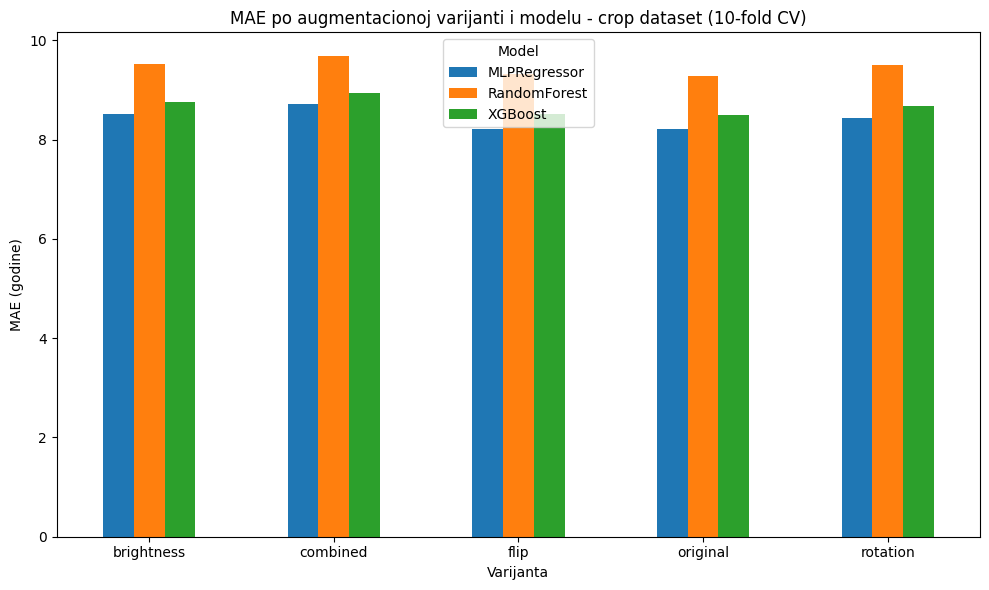

In [57]:
pivot_mae = results_df_crop.pivot(index="Varijanta", columns="Model", values="MAE")
# iz tabele pravim novu tabelu za mae

pivot_mae.plot(kind="bar", figsize=(10, 6)) # crtam stubicasti grafikon
plt.ylabel("MAE (godine)")
plt.title("MAE po augmentacionoj varijanti i modelu - crop dataset (10-fold CV)")
plt.xticks(rotation=0)
plt.legend(title="Model")
plt.tight_layout()
plt.show()

In [58]:
results_df_crop.to_csv("results_crop_cv.csv", index=False) # cuvamo tabelu kao csv
print("Rezultati (10-fold CV) sacuvani u results_crop_cv.csv")

Rezultati (10-fold CV) sacuvani u results_crop_cv.csv


#### 3.3.1. Finalna evaluacija na test skupu 

Bira se kombinacija (augmentaciona varijanta + model) sa najnižim prosečnim MAE dobijenim **10-strukom unakrsnom validacijom (10-fold CV)** nad trening skupom. Ta kombinacija (model koji je već treniran nad celim trening skupom u okviru 'train_and_evaluate') se zatim ocenjuje na test skupu.

Test skup do ovog trenutka nije korišćen ni za treniranje modela, ni za CV, ni za odabir najbolje varijante, čime se izbegava curenje informacija (data leakage) iz procesa odabira u finalnu ocenu performansi.


In [59]:
# biramo najbolju kombinaciju (varijanta + model) po prosecnom MAE iz 10-fold CV
best_row = results_df_crop.loc[results_df_crop["MAE"].idxmin()] # trazimo red s najmanjim mae

best_variant = best_row["Varijanta"] # izdvajam najb aug
best_model_name = best_row["Model"] # i najb model

# ispisujemo rez
print(f"Najbolja kombinacija na osnovu 10-fold CV: {best_variant} + {best_model_name}")
print(f"CV MAE: {best_row['MAE']:.2f} (+/- {best_row['MAE_std']:.2f})  "
      f"CV RMSE: {best_row['RMSE']:.2f} (+/- {best_row['RMSE_std']:.2f})")

Najbolja kombinacija na osnovu 10-fold CV: original + MLPRegressor
CV MAE: 8.22 (+/- 0.06)  CV RMSE: 10.73 (+/- 0.07)


In [60]:
# uzimamo vec istrenirani model i scaler te kombinacije (bez ponovnog treniranja)
best_model = all_results_crop[best_variant][best_model_name]["model"]
best_scaler = all_results_crop[best_variant][best_model_name]["scaler"]

# skaliramo test skup ISTIM scalerom koji je koriscen za treniranje najbolje kombinacije
X_test_scaled = best_scaler.transform(X_test_feat)

test_preds = best_model.predict(X_test_scaled) # model predvidja godine

test_mae = mean_absolute_error(y_test_feat, test_preds) # racunamo mae
test_rmse = np.sqrt(mean_squared_error(y_test_feat, test_preds)) # i rmse

print(f"Finalni rezultat na test skupu ({best_variant} + {best_model_name}):") # ispisujemo sta smo testirali
print(f"  MAE:  {test_mae:.2f}") # mae
print(f"  RMSE: {test_rmse:.2f}") # i rmse

Finalni rezultat na test skupu (original + MLPRegressor):
  MAE:  8.14
  RMSE: 10.67


In [61]:
# dodajemo test rezultat u posebnu tabelu radi lakseg poredjenja u Fazi 3 (crop vs clean)
final_test_row_crop = pd.DataFrame([{
    "Dataset": "crop",
    "Varijanta": best_variant,
    "Model": best_model_name,
    "Split": "test",
    "MAE": test_mae,
    "RMSE": test_rmse,
}])

final_test_row_crop.to_csv("results_crop_test.csv", index=False)
final_test_row_crop

,Dataset,Varijanta,Model,Split,MAE,RMSE
0,crop,original,MLPRegressor,test,8.143298,10.672891


In [62]:
import joblib # za cuvanje finalnog modela i scalera na disk

os.makedirs("models_crop", exist_ok=True) # pravljenje foldera za modele

# cuvanje najb modela i scalera
joblib.dump(best_model, f"models_crop/best_model_{best_variant}_{best_model_name}.joblib")
joblib.dump(best_scaler, f"models_crop/best_scaler_{best_variant}_{best_model_name}.joblib")

print("Sacuvan finalni model i scaler u models_crop/")

Sacuvan finalni model i scaler u models_crop/


## 4. Clean verzija dataseta

Ceo pajplajn iznad će biti ponovljen na IMDB-WIKI clean verziji, koristeći iste funkcije ('make_dataset', 'extract_features', 'train_and_evaluate'), menja se samo izvor podataka (učitavanje CSV-a).

Na kraju rezultati ('results_df_crop' i 'results_df_clean') će biti spojeni i upoređeni u zajedničkoj tabeli, kako bi se odgovorilo na pitanje: **da li čistiji dataset daje bolje rezultate, i da li se odgovor na "koja augmentacija najviše pomaže" menja u zavisnosti od dataseta.**

### 4.1. Učitavanje (train/valid/test CSV)

IMDB-Clean dataset je već podeljen na train/valid/test CSV fajlove ('imdb_train_new_1024.csv', 'imdb_valid_new_1024.csv', 'imdb_test_new_1024.csv'), sa kolonama 'filename', 'age', 'gender' (M/F), bounding box lica ('x_min,y_min,x_max,y_max') i uglom glave ('head_roll/yaw/pitch'). Pošto je split već gotov (napravljen constrained clustering metodom, tako da iste osobe ne završe u više skupova), ovde ga samo učitavamo.

Pošto se za odabir najbolje augmentacione varijante i modela sada koristi 10-struka unakrsna validacija (10-fold CV) nad trening skupom, a ne poseban validacioni skup, zvanični train i valid CSV se **spajaju u jedinstven trening skup** ('df_train_clean_full') nad kojim se dalje radi CV. Zvanični test skup ostaje potpuno odvojen i koristi se isključivo za finalnu evaluaciju.

In [3]:
CLEAN_IMAGES_DIR = "archive/imdb-clean-1024/imdb-clean-1024"  # folder u koji su raspakovane slike

def load_clean_split(csv_path): # fja za ucitavanje csv fajla
    d = pd.read_csv(csv_path)
    d["path"] = CLEAN_IMAGES_DIR + "/" + d["filename"]  # dodajemo putanju do foldera sa slikama
    return d

df_train_clean = load_clean_split("archive/imdb_train_new_1024.csv") # ucitavamo train skup
df_val_clean = load_clean_split("archive/imdb_valid_new_1024.csv") # validation skup
df_test_clean = load_clean_split("archive/imdb_test_new_1024.csv") # test skup

print("Train:", df_train_clean.shape)
print("Valid:", df_val_clean.shape)
print("Test:", df_test_clean.shape)

# spajamo zvanicni train i valid u jedinstven trening skup - koristi se dalje
# za 10-fold CV, pa poseban validacioni skup vise nije potreban
df_train_clean_full = pd.concat([df_train_clean, df_val_clean], ignore_index=True)
print("Train+Valid spojeno (koristi se za CV):", df_train_clean_full.shape)

df_train_clean.head()

Train: (183887, 11)
Valid: (45972, 11)
Test: (56087, 11)
Train+Valid spojeno (koristi se za CV): (229859, 11)


,filename,age,gender,x_min,y_min,x_max,y_max,head_roll,head_yaw,head_pitch,path
0,05/nm0200005_rm3512895744_1959-12-24_2009.jpg,50,M,78.0,93.0,155.0,185.0,20.134891,-34.811884,-5.720485,archive/imdb-clean-1024/imdb-clean-1024/05/nm0...
1,02/nm0001002_rm1464638208_1966-7-31_2006.jpg,40,M,123.0,175.0,245.0,349.0,11.789708,23.570937,-18.610900,archive/imdb-clean-1024/imdb-clean-1024/02/nm0...
2,00/nm0000100_rm103389184_1955-1-6_2005.jpg,50,M,52.0,70.0,103.0,139.0,0.209951,-20.153913,-13.759556,archive/imdb-clean-1024/imdb-clean-1024/00/nm0...
3,04/nm0024404_rm2909178368_1978-2-20_2009.jpg,31,F,28.0,38.0,55.0,75.0,9.971704,-10.203414,-1.376687,archive/imdb-clean-1024/imdb-clean-1024/04/nm0...
4,00/nm0703800_rm31823616_1959-6-6_2008.jpg,49,M,69.0,100.0,137.0,199.0,5.041017,14.441552,12.871575,archive/imdb-clean-1024/imdb-clean-1024/00/nm0...


In [4]:
# provera da putanja stvarno vodi do slike na disku
from PIL import Image

img = Image.open(df_train_clean["path"].iloc[0])
print("Putanja:", df_train_clean["path"].iloc[0])
print("Dimenzije slike:", img.size)

Putanja: archive/imdb-clean-1024/imdb-clean-1024/05/nm0200005_rm3512895744_1959-12-24_2009.jpg
Dimenzije slike: (234, 279)


In [5]:
df_train_clean["age"].describe() # distribucija godina u train skupu

count    183887.000000
mean         36.996955
std          12.687647
min           1.000000
25%          28.000000
50%          35.000000
75%          44.000000
max          95.000000
Name: age, dtype: float64

#### 4.1.1. Uzorkovanje podskupa 

Isto kao kod crop verzije, 'USE_SUBSET' prekidač koristi se da se pipeline prvo testira na manjem podskupu. Pošto se trening i validacioni CSV već koriste spojeno ('df_train_clean_full'), a poseban validacioni skup više nije potreban (koristi se 10-fold CV), podskup pravimo tako što 'SUBSET_SIZE' raspodelimo u razmeri **85% trening / 15% test**, a zatim iz svakog skupa uzorkujemo ravnomerno po starosnim binovima.


In [8]:
def stratified_subset(d, n, random_state=RANDOM_STATE):
    # ravnomeran uzorak po starosnim binovima
    d = d.copy() # kopiramo df
    d["age_bin"] = pd.cut(d["age"], bins=10) # pravimo starosne grupe

    sub = ( # biramo uzorke iz svakog age bina
        d.groupby("age_bin", observed=True, group_keys=False)
         .apply(lambda x: x.sample(
             n=min(len(x), n // d["age_bin"].nunique()),
             random_state=random_state
         ))
    )
    return sub.drop(columns=["age_bin"]).reset_index(drop=True)

if USE_SUBSET:
    TRAIN_SUBSET = int(SUBSET_SIZE * 0.85) # train 85%
    TEST_SUBSET = SUBSET_SIZE - TRAIN_SUBSET # test 15%

    # pravljenje clean datasetova
    df_train_clean_subset = stratified_subset(df_train_clean_full, TRAIN_SUBSET)
    df_test_clean_subset = stratified_subset(df_test_clean, TEST_SUBSET)
else:
    # ne uzimamo subset vec sve slike
    df_train_clean_subset = df_train_clean_full.reset_index(drop=True)
    df_test_clean_subset = df_test_clean.reset_index(drop=True)

print("Broj slika koje se koriste (clean) - train:", len(df_train_clean_subset))
print("Broj slika koje se koriste (clean) - test:", len(df_test_clean_subset))

Broj slika koje se koriste (clean) - train: 229859
Broj slika koje se koriste (clean) - test: 56087


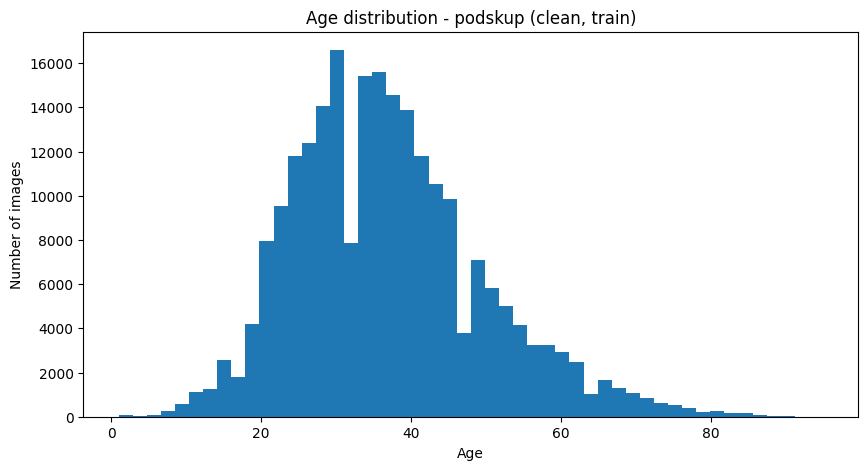

In [9]:
plt.figure(figsize=(10,5))
plt.hist(df_train_clean_subset["age"], bins=50)
plt.xlabel("Age")
plt.ylabel("Number of images")
plt.title("Age distribution - podskup (clean, train)")
plt.show()

#### 4.1.2. Priprema podataka i augmentacione varijante 

Koristimo iste funkcije definisane ranije u notebook-u za crop verziju ('load_image_with_aug', 'make_dataset', 'IMG_SIZE', 'BATCH_SIZE', 'AUGMENTATIONS' rečnik).

In [10]:
# odvajamo ulazne podatke i ciljnu vr
X_train_clean = df_train_clean_subset["path"]
y_train_clean = df_train_clean_subset["age"]

X_test_clean = df_test_clean_subset["path"]
y_test_clean = df_test_clean_subset["age"]

print(X_train_clean.shape, X_test_clean.shape)

(229859,) (56087,)


In [18]:
# val i test skup bez augmentacije 
test_ds_clean = make_dataset(X_test_clean, y_test_clean, aug_layer=None)

# train skup, po jedna verzija za svaku augmentacionu varijantu
train_datasets_clean = {
    name: make_dataset(X_train_clean, y_train_clean, aug_layer=aug_layer, shuffle=True)
    for name, aug_layer in AUGMENTATIONS.items()
}

print("Napravljeno train_ds varijanti (clean):", list(train_datasets_clean.keys()))

Napravljeno train_ds varijanti (clean): ['original', 'flip', 'rotation', 'brightness', 'combined']


#### 4.1.3. MobileNet - ekstrakcija obeležja

Koristi se isti 'feature_extractor' (MobileNet), ponovo se poziva 'extract_features'.

In [23]:
FEATURES_DIR_CLEAN = "features_clean"
os.makedirs(FEATURES_DIR_CLEAN, exist_ok=True) # pravimo folder

# ekstrakcija featura za val i test
X_test_feat_clean, y_test_feat_clean = extract_features(test_ds_clean, feature_extractor)

# cuvamo val i test feature-e
np.save(f"{FEATURES_DIR_CLEAN}/test_features.npy", X_test_feat_clean)
np.save(f"{FEATURES_DIR_CLEAN}/test_labels.npy", y_test_feat_clean)

print("Test features (clean):", X_test_feat_clean.shape)

2026-08-25 13:12:08.664254: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.
2026-08-25 13:15:06.521425: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Test features (clean): (56087, 1024)


In [24]:
# train, ekstrakcija za svih 5 augmentacionih varijanti za clean
train_features_clean = {}
train_labels_clean = {}

for name, ds in train_datasets_clean.items():
    print(f"Ekstrakcija obelezja za varijantu (clean): {name} ...")
    X_feat, y_feat = extract_features(ds, feature_extractor)

    train_features_clean[name] = X_feat
    train_labels_clean[name] = y_feat

    np.save(f"{FEATURES_DIR_CLEAN}/train_{name}_features.npy", X_feat)
    np.save(f"{FEATURES_DIR_CLEAN}/train_{name}_labels.npy", y_feat)

    print(f"  {X_feat.shape}")

print("Sve varijante su izvucene i sacuvane (clean).")

Ekstrakcija obelezja za varijantu (clean): original ...


2026-08-25 13:27:12.950162: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


  (229859, 1024)
Ekstrakcija obelezja za varijantu (clean): flip ...
  (229859, 1024)
Ekstrakcija obelezja za varijantu (clean): rotation ...


2026-08-25 13:51:22.540028: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


  (229859, 1024)
Ekstrakcija obelezja za varijantu (clean): brightness ...
  (229859, 1024)
Ekstrakcija obelezja za varijantu (clean): combined ...
  (229859, 1024)
Sve varijante su izvucene i sacuvane (clean).


### 4.2. Treniranje regresionih modela

Koristi se ista 'train_and_evaluate' funkcija (MLPRegressor, RandomForest, XGBoost).

In [27]:
# treniranje na svih 5 augmentacionih varijanti (clean verzija)
all_results_clean = {}

for variant_name in train_features_clean.keys():
    print(f"\n Varijanta: {variant_name} ")
    all_results_clean[variant_name] = train_and_evaluate(
        train_features_clean[variant_name],
        train_labels_clean[variant_name],
    )


 Varijanta: original 
  10-fold CV za MLPRegressor ...
    CV MAE: 7.99 +/- 0.04   CV RMSE: 10.23 +/- 0.06
  10-fold CV za RandomForest ...
    CV MAE: 8.81 +/- 0.04   CV RMSE: 11.25 +/- 0.05
  10-fold CV za XGBoost ...
    CV MAE: 8.19 +/- 0.03   CV RMSE: 10.49 +/- 0.05

 Varijanta: flip 
  10-fold CV za MLPRegressor ...
    CV MAE: 7.99 +/- 0.05   CV RMSE: 10.23 +/- 0.07
  10-fold CV za RandomForest ...
    CV MAE: 8.83 +/- 0.04   CV RMSE: 11.27 +/- 0.05
  10-fold CV za XGBoost ...
    CV MAE: 8.20 +/- 0.03   CV RMSE: 10.50 +/- 0.05

 Varijanta: rotation 
  10-fold CV za MLPRegressor ...
    CV MAE: 8.22 +/- 0.05   CV RMSE: 10.52 +/- 0.07
  10-fold CV za RandomForest ...
    CV MAE: 8.96 +/- 0.04   CV RMSE: 11.44 +/- 0.05
  10-fold CV za XGBoost ...
    CV MAE: 8.37 +/- 0.03   CV RMSE: 10.71 +/- 0.05

 Varijanta: brightness 
  10-fold CV za MLPRegressor ...
    CV MAE: 8.23 +/- 0.02   CV RMSE: 10.54 +/- 0.04
  10-fold CV za RandomForest ...
    CV MAE: 8.97 +/- 0.04   CV RMSE: 11.44

### 4.3. Rezultati - poređenje augmentacionih varijanti

In [28]:
# sredjujemo rezultate u preglednu tabelu (clean)
rows = []
for variant_name, model_results in all_results_clean.items():
    for model_name, res in model_results.items():
        rows.append({
            "Dataset": "clean",
            "Varijanta": variant_name,
            "Model": model_name,
            "MAE": res["MAE"],
            "MAE_std": res["MAE_std"],
            "RMSE": res["RMSE"],
            "RMSE_std": res["RMSE_std"],
        })

results_df_clean = pd.DataFrame(rows)
results_df_clean

,Dataset,Varijanta,Model,MAE,MAE_std,RMSE,RMSE_std
0,clean,original,MLPRegressor,7.990743,0.041641,10.233986,0.060393
1,clean,original,RandomForest,8.809742,0.036640,11.249277,0.046281
2,clean,original,XGBoost,8.191735,0.027817,10.488146,0.047441
3,clean,flip,MLPRegressor,7.991819,0.048057,10.232070,0.067769
4,clean,flip,RandomForest,8.826055,0.039449,11.269423,0.052398
5,clean,flip,XGBoost,8.197811,0.031122,10.496352,0.052766
6,clean,rotation,MLPRegressor,8.217603,0.046895,10.519369,0.074658
7,clean,rotation,RandomForest,8.961601,0.042261,11.440638,0.049326
8,clean,rotation,XGBoost,8.369638,0.032932,10.713139,0.053796
9,clean,brightness,MLPRegressor,8.227884,0.015822,10.537220,0.039878


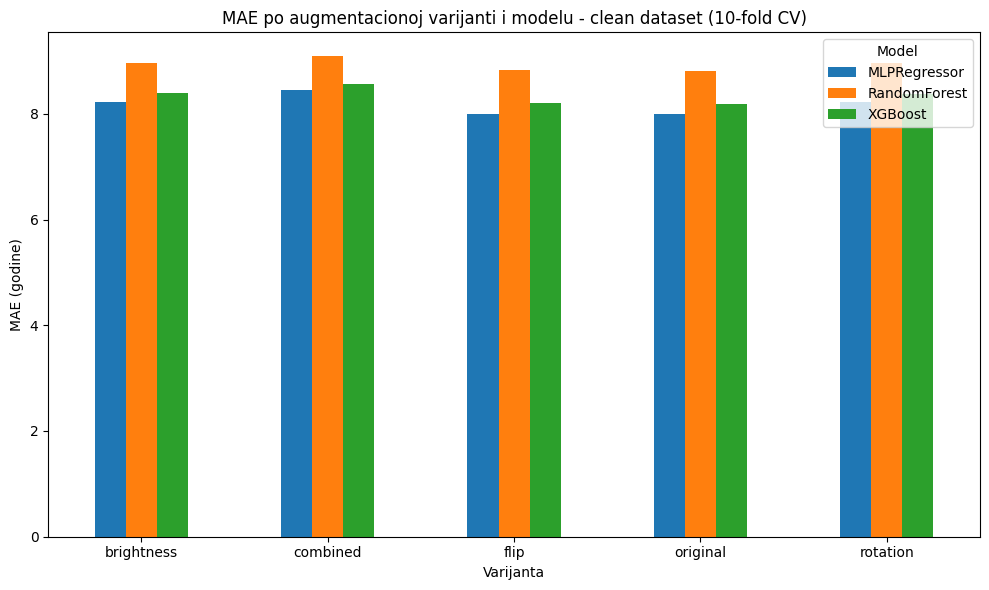

In [29]:
pivot_mae_clean = results_df_clean.pivot(index="Varijanta", columns="Model", values="MAE")

pivot_mae_clean.plot(kind="bar", figsize=(10, 6))
plt.ylabel("MAE (godine)")
plt.title("MAE po augmentacionoj varijanti i modelu - clean dataset (10-fold CV)")
plt.xticks(rotation=0)
plt.legend(title="Model")
plt.tight_layout()
plt.show()

In [30]:
results_df_clean.to_csv("results_clean_cv.csv", index=False)
print("Rezultati (10-fold CV) sacuvani u results_clean_cv.csv")

Rezultati (10-fold CV) sacuvani u results_clean_cv.csv


#### 4.3.1. Finalna evaluacija na test skupu 

Bira se kombinacija (augmentaciona varijanta + model) sa najnižim prosečnim MAE dobijenim 10-strukom unakrsnom validacijom (10-fold CV) nad trening skupom ('df_train_clean_full', spojeni zvanični train + valid). Ta kombinacija, već istrenirana nad celim trening skupom u okviru 'train_and_evaluate', ocenjuje se na zvaničnom, do sada nekorišćenom test skupu.


In [31]:
# biramo najbolju kombinaciju (varijanta + model) po MAE na validacionom skupu (clean)
best_row_clean = results_df_clean.loc[results_df_clean["MAE"].idxmin()]

best_variant_clean = best_row_clean["Varijanta"]
best_model_name_clean = best_row_clean["Model"]

print(f"Najbolja kombinacija na osnovu 10-fold CV (clean): {best_variant_clean} + {best_model_name_clean}")
print(f"CV MAE: {best_row_clean['MAE']:.2f} (+/- {best_row_clean['MAE_std']:.2f})  "
      f"CV RMSE: {best_row_clean['RMSE']:.2f} (+/- {best_row_clean['RMSE_std']:.2f})")


Najbolja kombinacija na osnovu 10-fold CV (clean): original + MLPRegressor
CV MAE: 7.99 (+/- 0.04)  CV RMSE: 10.23 (+/- 0.06)


In [32]:
# uzimamo model i scaler te kombinacije - vec istreniran nad CELIM trening skupom
# (train+valid spojeno) unutar train_and_evaluate, pa ga ovde ne treniramo ponovo
best_model_clean = all_results_clean[best_variant_clean][best_model_name_clean]["model"]
best_scaler_clean = all_results_clean[best_variant_clean][best_model_name_clean]["scaler"]

# skaliramo test feature-e
X_test_scaled_clean = best_scaler_clean.transform(X_test_feat_clean)

# model predvidja godine
test_preds_clean = best_model_clean.predict(X_test_scaled_clean)

# racunamo mae i rmse
test_mae_clean = mean_absolute_error(y_test_feat_clean, test_preds_clean)
test_rmse_clean = np.sqrt(mean_squared_error(y_test_feat_clean, test_preds_clean))

print(f"Test MAE (clean): {test_mae_clean:.2f}  RMSE: {test_rmse_clean:.2f}")

Test MAE (clean): 8.36  RMSE: 10.74


In [33]:
# pravimo df sa knacnim clean rez
final_test_row_clean = pd.DataFrame([{
    "Dataset": "clean",
    "Varijanta": best_variant_clean,
    "Model": best_model_name_clean,
    "Split": "test",
    "MAE": test_mae_clean,
    "RMSE": test_rmse_clean,
}])

final_test_row_clean.to_csv("results_clean_test.csv", index=False)
final_test_row_clean

,Dataset,Varijanta,Model,Split,MAE,RMSE
0,clean,original,MLPRegressor,test,8.364326,10.744873


In [34]:
import joblib # za cuvanje finalnog modela i scalera na disk
# cuvamo model i scaler
os.makedirs("models_clean", exist_ok=True)

joblib.dump(best_model_clean, f"models_clean/best_model_{best_variant_clean}_{best_model_name_clean}.joblib")
joblib.dump(best_scaler_clean, f"models_clean/best_scaler_{best_variant_clean}_{best_model_name_clean}.joblib")

print("Sacuvan finalni model i scaler u models_clean/")

Sacuvan finalni model i scaler u models_clean/


## 5. Poređenje crop vs clean

Spajamo rezultate ('results_df_crop', 'final_test_row_crop') i ('results_df_clean', 'final_test_row_clean') da vidimo da li je čistiji dataset (clean) dao bolje rezultate od crop verzije, i da li je uticaj augmentacije isti na obe verzije podataka.

In [35]:
results_df_crop = pd.read_csv("results_crop_cv.csv")
results_df_clean = pd.read_csv("results_clean_cv.csv")

results_df_all = pd.concat(
    [results_df_crop, results_df_clean],
    ignore_index=True
)

results_df_all.to_csv("results_all_cv.csv", index=False)

results_df_all

,Dataset,Varijanta,Model,MAE,MAE_std,RMSE,RMSE_std
0,crop,original,MLPRegressor,8.220142,0.057864,10.729919,0.074354
1,crop,original,RandomForest,9.283421,0.042805,11.909254,0.049335
2,crop,original,XGBoost,8.493826,0.049054,11.005695,0.057919
3,crop,flip,MLPRegressor,8.223151,0.038682,10.746155,0.065021
4,crop,flip,RandomForest,9.315656,0.034152,11.932190,0.041351
5,crop,flip,XGBoost,8.511277,0.042757,11.026956,0.049459
6,crop,rotation,MLPRegressor,8.434045,0.043557,10.989608,0.055613
7,crop,rotation,RandomForest,9.495842,0.031345,12.118989,0.035961
8,crop,rotation,XGBoost,8.684104,0.037324,11.227441,0.037973
9,crop,brightness,MLPRegressor,8.517834,0.053609,11.096970,0.050283


In [36]:
# uporedni prikaz MAE (10-fold CV) crop vs clean, po aug i modelu
pivot_compare = results_df_all.pivot_table(index="Varijanta", columns=["Dataset", "Model"], values="MAE")
pivot_compare

Dataset           clean                                crop               \
Model      MLPRegressor RandomForest   XGBoost MLPRegressor RandomForest   
Varijanta                                                                  
brightness     8.227884     8.968085  8.386742     8.517834     9.521831   
combined       8.449450     9.086802  8.570734     8.717341     9.679838   
flip           7.991819     8.826055  8.197811     8.223151     9.315656   
original       7.990743     8.809742  8.191735     8.220142     9.283421   
rotation       8.217603     8.961601  8.369638     8.434045     9.495842   

Dataset               
Model        XGBoost  
Varijanta             
brightness  8.751510  
combined    8.935809  
flip        8.511277  
original    8.493826  
rotation    8.684104

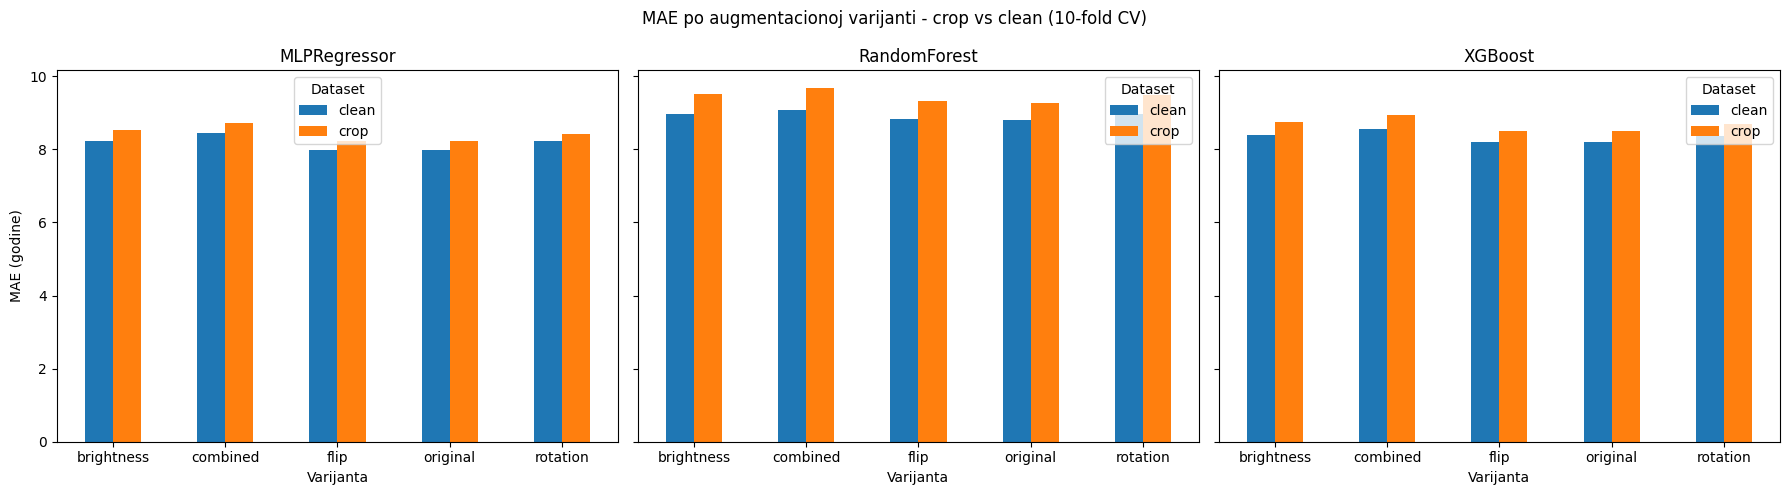

In [37]:
# graficki prikaz mae za crop i clean
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, model_name in zip(axes, ["MLPRegressor", "RandomForest", "XGBoost"]):
    sub = results_df_all[results_df_all["Model"] == model_name]
    pivot = sub.pivot(index="Varijanta", columns="Dataset", values="MAE")
    pivot.plot(kind="bar", ax=ax)
    ax.set_title(model_name)
    ax.set_ylabel("MAE (godine)")
    ax.tick_params(axis="x", rotation=0)

plt.suptitle("MAE po augmentacionoj varijanti - crop vs clean (10-fold CV)")
plt.tight_layout()
plt.show()

In [38]:
final_test_row_crop = pd.read_csv("results_crop_test.csv")
final_test_row_clean = pd.read_csv("results_clean_test.csv")

final_test_all = pd.concat(
    [final_test_row_crop, final_test_row_clean],
    ignore_index=True
)

final_test_all.to_csv("results_all_test.csv", index=False)

final_test_all

,Dataset,Varijanta,Model,Split,MAE,RMSE
0,crop,original,MLPRegressor,test,8.143298,10.672891
1,clean,original,MLPRegressor,test,8.364326,10.744873


## 6. Zaključak

Poređenjem MAE/RMSE vrednosti između crop i clean verzije skupa podataka, na osnovu 10-strukog unakrsne validacije (svih 15 kombinacija varijanti i modela po datasetu) na trening skupu, **clean verzija** je dala niži (bolji) MAE u svih 15/15 uparenih poređenja (isti model + ista augmentaciona varijanta, samo različit dataset). **Prosečan CV MAE iznosi 8.85 za crop naspram 8.48 za clean** (RMSE: 11.43 naspram 10.85). Poboljšanje je konzistentno po svim kombinacijama, što ukazuje da je **čišćenje podataka sistematski korisno**, a ne slučajan efekat jedne kombinacije.

Kada je reč o augmentacionim varijantama, redosled po prosečnom CV MAE (preko sva tri modela) je identičan za oba dataseta: **original < flip < rotation < brightness < combined**. Varijanta bez ikakve augmentacije **(original) daje najniži (najbolji) MAE**, dok **kombinovana augmentacija (combined) daje najviši (najlošiji) MAE**, na oba dataseta. Flip je jedina augmentacija koja je gotovo izjednačena sa original varijantom (razlika CV MAE ~0.02), dok rotation i brightness, a naročito njihova kombinacija, dosledno pogoršavaju rezultat.

**Najbolji pojedinačni rezultat** na osnovu 10-fold CV ostvaren je kombinacijom **clean / original / MLPRegressor (CV MAE = 7.99, CV RMSE = 10.23)**, dok je **MLPRegressor generalno najbolji model za oba dataseta (prosečan MAE 8.42 na crop, 8.18 na clean)**, XGBoost je drugi (8.68 / 8.34), a RandomForest je konzistentno najslabiji (9.46 / 8.93), poredak modela je isti na oba dataseta.

Na test skupu je testirana kombinacija koja se pokazala najboljom na 10-fold CV (varijanta original, model MLPRegressor), za oba dataseta. Poredak sa CV se delimično ne poklapa: **na test skupu crop verzija (MAE = 8.14, RMSE = 10.67) je dala nešto bolji rezultat od clean verzije (MAE = 8.36, RMSE = 10.74), iako je clean tokom CV bio bolji za istu kombinaciju (7.99 naspram 8.22)**. Razlika je relativno mala (~0.2 MAE) i može se pripisati specifičnosti pojedinačnog test skupa (drugačija raspodela/šum u odnosu na trening skup), ali ukazuje da **prednost clean verzije**, iako dosledna tokom unakrsne validacije, nije garantovana na svakom pojedinačnom test skupu istom veličinom margine.

**Da li čišćenje podataka (clean) doprinosi više od same augmentacije, ili obrnuto?**

Na osnovu 10-fold CV rezultata, čišćenje podataka ima znatno veći i konzistentniji uticaj na performanse od augmentacije: **prelazak sa crop na clean donosi poboljšanje MAE od u proseku ~0.37 u svih 15/15 poređenja**, dok **augmentacija, umesto da pomogne, u ovom eksperimentu blago pogoršava rezultate u odnosu na original varijantu** (najviše kod combined, do ~0.4 MAE lošije). Ovaj nalaz je u skladu sa uvodnom napomenom rada da **augmentacija ne rešava problem šuma u podacima (pogrešne godine, loši kropovi), već treba da poveća robusnost modela na varijacije poput ugla, osvetljenja ili orijentacije lica**, varijacije koje kod ovog problema (IMDB-WIKI, MobileNet feature extractor) očigledno nisu bile ograničavajući faktor, dok je kvalitet/tačnost oznaka (godina) i kvalitet kropovanja bio. Test rezultati delimično ublažavaju ovaj zaključak (crop je na test skupu bio marginalno bolji za istu kombinaciju), ali razlika je mala i ne menja opšti trend iz CV analize da je čišćenje podataka dominantniji faktor od izbora augmentacije.